<a href="https://colab.research.google.com/github/mariadoloressss/Computacional/blob/main/OBLIGATORIO_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OBLIGATORIO 3. **Resolución de ecuaciones en derivadas parciales: la ecuación de Schrödinger**

Este trabajo ha sido realizado en colaboración por Carmen Bonal de Manuel, Pau Gomila Tarongí, Claudia González Arnaiz, Mario Hernández Cuéllar, María Dolores Navarro Ortiz y Clara Piñero García.

# Herramientas
Para escribir el código que resuelve numéricamente la ecuación de Schrödinger unidimensional para un potencial cuadrado, se ha utilizado inteligencia artificial generativa como herramienta de apoyo a la programación y a la estructuración del trabajo.

En concreto, el modelo ha servido como motor de metaprogramación, ayudando a transformar el planteamiento físico del problema en una implementación computacional en Python. A partir de la ecuación de Schrödinger dependiente del tiempo, la IA ha facilitado la organización del código en bloques diferenciados: definición de parámetros, construcción de la función de onda inicial, definición del potencial cuadrado, resolución del sistema tridiagonal, evolución temporal, representación gráfica y cálculo aproximado de las probabilidades de reflexión y transmisión.

A nivel conceptual, la IA ha actuado como un orquestador semántico, interpretando el problema físico y guiando la elección de las herramientas numéricas necesarias. En este caso, se ha empleado el método de Cayley para la evolución temporal, ya que permite conservar la norma de la función de onda y mantener la interpretación probabilística del sistema. Además, el modelo ha ayudado a relacionar las expresiones matemáticas del método con su correspondiente implementación mediante arrays complejos en Python.

En la capa de ejecución, la IA ha contribuido a estructurar un código claro y modular, usando librerías como `numpy` para el cálculo numérico y `matplotlib` para la representación gráfica y la animación de la densidad de probabilidad $|\Phi(x,t)|^2$. También se ha incluido la comprobación de la conservación de la norma, aspecto fundamental para verificar que el método numérico utilizado es adecuado.

Finalmente, la IA ha servido como apoyo en la interpretación de los resultados obtenidos, especialmente en el cálculo aproximado de los coeficientes de reflexión, transmisión y probabilidad dentro de la barrera. Estos valores permiten analizar el comportamiento del paquete de ondas al interactuar con el potencial cuadrado y visualizar fenómenos propios de la mecánica cuántica, como la transmisión parcial a través de una barrera.

En conjunto, el uso de inteligencia artificial generativa no sustituye el análisis físico ni la comprensión del método numérico, sino que introduce una capa de asistencia y metaprogramación que permite organizar el desarrollo, reducir errores de implementación y conectar de forma más directa la formulación matemática con el código computacional.

# 1. Introducción
En este trabajo se aborda la resolución numérica de la ecuación de Schrödinger unidimensional dependiente del tiempo, que describe la evolución de una partícula cuántica en presencia de un potencial externo. Esta ecuación es fundamental en mecánica cuántica, ya que permite determinar la función de onda del sistema, cuyo módulo al cuadrado representa la densidad de probabilidad de encontrar la partícula en una determinada posición.

El problema considerado consiste en el estudio de la propagación de un paquete de ondas gaussiano que incide sobre una barrera de potencial cuadrado. Este tipo de configuración permite analizar fenómenos característicos de la mecánica cuántica, como la reflexión y la transmisión a través de barreras de potencial, incluyendo el efecto túnel.

Dado que, en general, la ecuación de Schrödinger no puede resolverse analíticamente para potenciales arbitrarios, se recurre a métodos numéricos. En este caso, se utiliza una discretización del espacio y del tiempo junto con el método de Cayley, que proporciona un esquema de evolución temporal unitario. Esta propiedad es esencial, ya que garantiza la conservación de la norma de la función de onda, requisito necesario para mantener la interpretación probabilística del sistema.

El algoritmo implementado permite simular la evolución temporal del sistema, visualizar la densidad de probabilidad y analizar la conservación de la norma. Además, se calculan de forma aproximada los coeficientes de reflexión y transmisión, que caracterizan el comportamiento de la partícula al interactuar con la barrera de potencial.

# 2. Fundamento teórico

La mecánica cuántica describe el estado de una partícula mediante una función de onda compleja $\Phi(x,t)$, cuya evolución temporal viene determinada por la ecuación de Schrödinger dependiente del tiempo:

$$
i\hbar \frac{\partial \Phi(x,t)}{\partial t}
=
\left[
-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}
+ V(x)
\right]\Phi(x,t)
$$

donde $V(x)$ representa el potencial externo al que está sometida la partícula.

El significado físico de la función de onda viene dado por la interpretación de Born, según la cual:

$$
|\Phi(x,t)|^2
$$

representa la densidad de probabilidad de encontrar la partícula en la posición $x$ en el instante $t$. Por ello, la función de onda debe satisfacer la condición de normalización:

$$
\int |\Phi(x,t)|^2 dx = 1
$$

Esta propiedad debe conservarse durante toda la evolución temporal del sistema.

Para simplificar la ecuación, es habitual trabajar con unidades reescaladas en las que $\hbar = 1$ y $m = 1/2$. En estas condiciones, la ecuación de Schrödinger se reduce a:

$$
i \frac{\partial \Phi}{\partial t}
=
\left[
-\frac{\partial^2}{\partial x^2}
+ V(x)
\right]\Phi
$$

El operador que aparece en esta ecuación se denomina Hamiltoniano:

$$
H =
-
\frac{\partial^2}{\partial x^2}
+
V(x)
$$

La ecuación de Schrödinger puede escribirse de forma compacta como:

$$
i \frac{\partial \Phi}{\partial t} = H\Phi
$$

La solución formal de esta ecuación viene dada por:

$$
\Phi(x,t) = e^{-iHt}\Phi(x,0)
$$

El operador de evolución temporal $e^{-iHt}$ es unitario, lo que garantiza la conservación de la norma de la función de onda a lo largo del tiempo.

En este trabajo se estudia el comportamiento de un paquete de ondas gaussiano que incide sobre una barrera de potencial. La función de onda inicial se toma como:

$$
\Phi(x,0)
=
e^{ik_0 x}
e^{-\frac{(x-x_0)^2}{2\sigma^2}}
$$

donde $k_0$ es el número de onda, $x_0$ la posición inicial del paquete y $\sigma$ su anchura.

El potencial considerado es una barrera cuadrada, definida como:

$$
V(x) =
\begin{cases}
0, & x \notin [a,b] \\
V_0, & x \in [a,b]
\end{cases}
$$

Este sistema permite estudiar fenómenos característicos de la mecánica cuántica como la reflexión y la transmisión de la función de onda al interactuar con la barrera. En particular, a diferencia de la física clásica, existe una probabilidad no nula de que la partícula atraviese la barrera incluso cuando su energía es menor que la altura del potencial, fenómeno conocido como efecto túnel.

El análisis de la evolución temporal de la función de onda permite calcular las probabilidades de reflexión y transmisión, que caracterizan el comportamiento del sistema.

# 3. Método numérico

Para resolver la ecuación de Schrödinger unidimensional se discretiza el espacio en $N+1$ puntos:

$$
x_j = jh, \qquad j = 0,1,\ldots,N
$$

donde:

$$
h = \frac{L}{N}
$$

También se discretiza el tiempo como:

$$
t_n = ns
$$

La función de onda en la red se representa mediante:

$$
\Phi(x_j,t_n) = \Phi_{j,n}
$$

En los extremos del intervalo se imponen condiciones de contorno de pared infinita:

$$
\Phi_{0,n}=0, \qquad \Phi_{N,n}=0
$$

La derivada segunda espacial se aproxima mediante diferencias finitas centradas:

$$
\frac{\partial^2 \Phi}{\partial x^2}
\approx
\frac{\Phi_{j+1,n}-2\Phi_{j,n}+\Phi_{j-1,n}}{h^2}
$$

Por tanto, el Hamiltoniano discretizado queda:

$$
H_D\Phi_{j,n}
=
-\frac{1}{h^2}
\left(
\Phi_{j+1,n}-2\Phi_{j,n}+\Phi_{j-1,n}
\right)
+
V_j\Phi_{j,n}
$$

Para la evolución temporal se utiliza la aproximación de Cayley:

$$
e^{-isH}
\approx
\frac{1-\frac{is}{2}H_D}
{1+\frac{is}{2}H_D}
$$

De esta forma, la función de onda en el siguiente paso temporal se calcula como:

$$
\Phi^{n+1}
=
\frac{1-\frac{is}{2}H_D}
{1+\frac{is}{2}H_D}
\Phi^n
$$

Este método tiene la ventaja de que conserva la norma de la función de onda, ya que el operador de evolución es unitario. Por tanto:

$$
\sum_j h|\Phi_{j,n}|^2 \approx 1
$$

Para implementar el método de forma eficiente, se introduce una función auxiliar $\chi^n$:

$$
\Phi^{n+1} = \chi^n - \Phi^n
$$

donde $\chi^n$ se obtiene resolviendo:

$$
\left(1+\frac{is}{2}H_D\right)\chi^n = 2\Phi^n
$$

Al sustituir el Hamiltoniano discretizado, se obtiene un sistema de ecuaciones tridiagonal:

$$
\chi_{j+1,n}
+
\left(
-2+\frac{2i}{\tilde{s}}-\tilde{V}_j
\right)\chi_{j,n}
+
\chi_{j-1,n}
=
\frac{4i}{\tilde{s}}\Phi_{j,n}
$$

donde:

$$
\tilde{s}=\frac{s}{h^2},
\qquad
\tilde{V}_j=h^2V_j
$$

Este sistema puede escribirse de forma general como:

$$
A_j^- \chi_{j-1,n}
+
A_j^0 \chi_{j,n}
+
A_j^+ \chi_{j+1,n}
=
b_{j,n}
$$

con:

$$
A_j^- = 1
$$

$$
A_j^0 = -2+\frac{2i}{\tilde{s}}-\tilde{V}_j
$$

$$
A_j^+ = 1
$$

$$
b_{j,n}=\frac{4i}{\tilde{s}}\Phi_{j,n}
$$

Para resolver el sistema tridiagonal se usa una relación de recurrencia:

$$
\chi_{j+1,n}=\alpha_j\chi_{j,n}+\beta_{j,n}
$$

con la condición final:

$$
\alpha_{N-1}=0,
\qquad
\beta_{N-1,n}=0
$$

Los coeficientes se calculan hacia atrás mediante:

$$
\gamma_j =
\frac{1}
{A_j^0+A_j^+\alpha_j}
$$

$$
\alpha_{j-1}
=
-A_j^-\gamma_j
$$

$$
\beta_{j-1,n}
=
\gamma_j
\left(
b_{j,n}-A_j^+\beta_{j,n}
\right)
$$

El coeficiente $\alpha_j$ solo depende del potencial y de los parámetros de discretización, por lo que se calcula una única vez antes de iniciar la evolución temporal. En cambio, $\beta_{j,n}$ depende de la función de onda en cada instante y debe recalcularse en cada paso temporal.

Una vez obtenidos $\alpha_j$ y $\beta_{j,n}$, se calcula $\chi$ hacia delante usando:

$$
\chi_{j+1,n}
=
\alpha_j\chi_{j,n}
+
\beta_{j,n}
$$

Finalmente, se actualiza la función de onda:

$$
\Phi_{j,n+1}
=
\chi_{j,n}
-
\Phi_{j,n}
$$

El algoritmo seguido en la simulación puede resumirse en los siguientes pasos:

1. Se fijan los parámetros iniciales $N$, $n_{\text{ciclos}}$ y $\lambda$.
2. Se calcula el paso espacial $h$, el número de onda reescalado $\tilde{k}_0$ y el paso temporal reescalado $\tilde{s}$.
3. Se construye la función de onda inicial gaussiana.
4. Se define el potencial cuadrado.
5. Se calculan los coeficientes $\alpha_j$.
6. En cada paso temporal se calculan los coeficientes $\beta_{j,n}$.
7. Se obtiene la función auxiliar $\chi$.
8. Se actualiza la función de onda mediante $\Phi^{n+1}=\chi^n-\Phi^n$.
9. Se comprueba la conservación de la norma durante la evolución.
10. Finalmente, se estiman las probabilidades de reflexión, transmisión y permanencia en la barrera.

# 4. Código y resultados

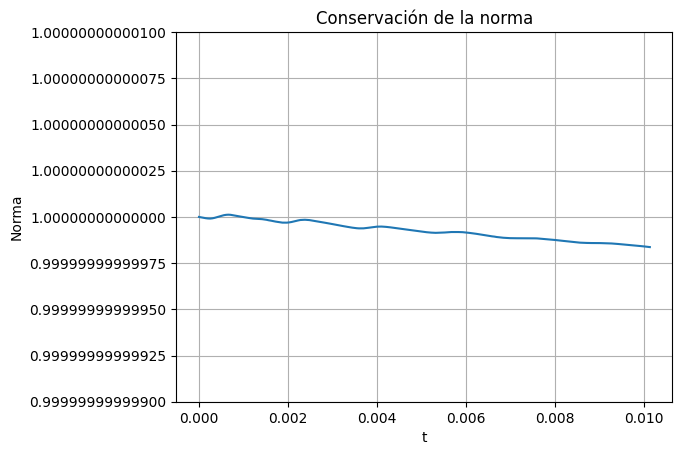

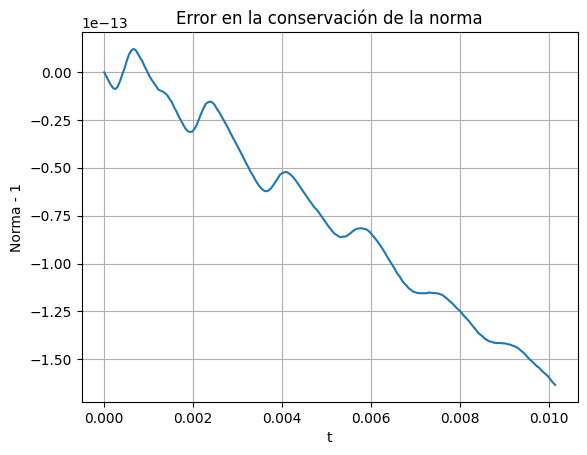

GIF guardado en:
/content/schrodinger_obligatorio.gif


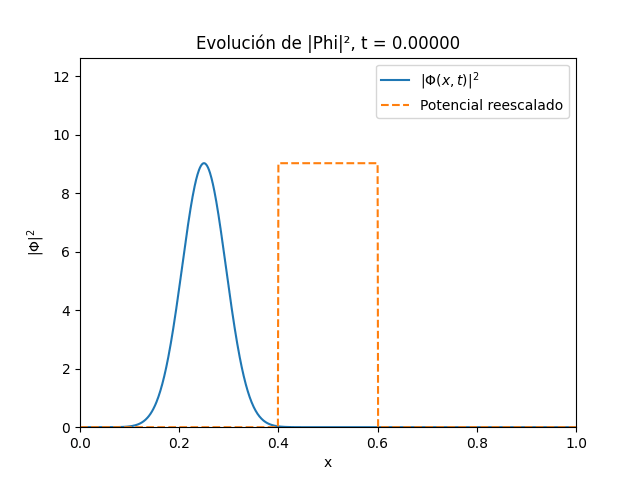

Coeficiente de reflexión aproximado R = 0.4814164226109858
Probabilidad dentro de la barrera B = 0.16906267151432863
Coeficiente de transmisión aproximado T = 0.3495209058745222
R + B + T = 0.9999999999998367
Norma final = 0.9999999999998367


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
import os

# ============================================================
# 1. PARÁMETROS
# ============================================================

N = 1000
L = 1.0
h = L / N

nciclos = 50
lam = 0.3

assert 1 <= nciclos <= N / 4, "nciclos debe estar entre 1 y N/4"

k_tilde = 2 * np.pi * nciclos / N
s_tilde = 1 / (4 * k_tilde**2)
s = s_tilde * h**2

nsteps = 4000
guardar_cada = 20

x = np.linspace(0, L, N + 1)
j = np.arange(N + 1)

# ============================================================
# 2. FUNCIÓN DE ONDA INICIAL
# ============================================================

x0 = L / 4
sigma = L / 16

phi = np.exp(1j * k_tilde * j) * np.exp(-(x - x0)**2 / (2 * sigma**2))

# Condiciones de contorno: paredes infinitas
phi[0] = 0
phi[-1] = 0

# Normalización inicial
norma_inicial = np.sqrt(np.sum(np.abs(phi)**2) * h)
phi = phi / norma_inicial

# ============================================================
# 3. POTENCIAL CUADRADO
# ============================================================

V_tilde = np.zeros(N + 1)

j1 = int(2 * N / 5)
j2 = int(3 * N / 5)

# Potencial cuadrado centrado en N/2, de anchura N/5
# Se incluye j2 porque el intervalo teórico es [2N/5, 3N/5]
V_tilde[j1:j2 + 1] = lam * k_tilde**2

# ============================================================
# 4. COEFICIENTES DEL SISTEMA TRIDIAGONAL
# ============================================================

A_minus = 1.0
A_plus = 1.0

A0 = -2 + 2j / s_tilde - V_tilde

alpha = np.zeros(N + 1, dtype=complex)
alpha[N - 1] = 0

# Cálculo de alpha, que no depende del tiempo
for jj in range(N - 1, 0, -1):
    gamma = 1 / (A0[jj] + A_plus * alpha[jj])
    alpha[jj - 1] = -A_minus * gamma

# ============================================================
# 5. FUNCIÓN DE EVOLUCIÓN TEMPORAL
# ============================================================

def evolucionar(phi):
    beta = np.zeros(N + 1, dtype=complex)
    beta[N - 1] = 0

    # Cálculo de beta
    for jj in range(N - 1, 0, -1):
        b = 4j * phi[jj] / s_tilde
        gamma = 1 / (A0[jj] + A_plus * alpha[jj])
        beta[jj - 1] = gamma * (b - A_plus * beta[jj])

    # Cálculo de chi usando la recurrencia hacia delante
    chi = np.zeros(N + 1, dtype=complex)
    chi[0] = 0
    chi[-1] = 0

    for jj in range(0, N):
        chi[jj + 1] = alpha[jj] * chi[jj] + beta[jj]

    # Evolución temporal mediante el método de Cayley
    phi_new = chi - phi

    # Condiciones de contorno
    phi_new[0] = 0
    phi_new[-1] = 0

    return phi_new

# ============================================================
# 6. SIMULACIÓN
# ============================================================

phis = []
normas = []
tiempos = []

for n in range(nsteps + 1):
    if n % guardar_cada == 0:
        phis.append(phi.copy())
        normas.append(np.sum(np.abs(phi)**2) * h)
        tiempos.append(n * s)

    if n < nsteps:
        phi = evolucionar(phi)

phis = np.array(phis)
normas = np.array(normas)
tiempos = np.array(tiempos)

# Estado final real de la simulación
phi_final = phi.copy()

# ============================================================
# 7. GRÁFICA DE LA NORMA
# ============================================================

plt.figure()
plt.plot(tiempos, normas)
plt.xlabel("t")
plt.ylabel("Norma")
plt.title("Conservación de la norma")
plt.ticklabel_format(useOffset=False)
plt.ylim(0.999999999999, 1.000000000001)
plt.grid()
plt.show()

plt.figure()
plt.plot(tiempos, normas - 1)
plt.xlabel("t")
plt.ylabel("Norma - 1")
plt.title("Error en la conservación de la norma")
plt.grid()
plt.show()

# ============================================================
# 8. ANIMACIÓN DE |PHI|²
# ============================================================

fig, ax = plt.subplots()

prob0 = np.abs(phis[0])**2
prob_max = np.max(prob0)

linea, = ax.plot(x, prob0, label=r"$|\Phi(x,t)|^2$")

if np.max(V_tilde) > 0:
    ax.plot(
        x,
        V_tilde / np.max(V_tilde) * prob_max,
        "--",
        label="Potencial reescalado"
    )

ax.set_xlim(0, L)
ax.set_ylim(0, prob_max * 1.4)
ax.set_xlabel("x")
ax.set_ylabel(r"$|\Phi|^2$")
ax.legend()

def actualizar(frame):
    prob = np.abs(phis[frame])**2
    linea.set_ydata(prob)
    ax.set_title(f"Evolución de |Phi|², t = {tiempos[frame]:.5f}")
    return linea,

anim = FuncAnimation(
    fig,
    actualizar,
    frames=len(phis),
    interval=40,
    blit=True
)

nombre_gif = "schrodinger_obligatorio.gif"

anim.save(nombre_gif, writer=PillowWriter(fps=25))

plt.close(fig)

print("GIF guardado en:")
print(os.path.abspath(nombre_gif))

display(Image(filename=nombre_gif))

# ============================================================
# 9. COEFICIENTES DE REFLEXIÓN, BARRERA Y TRANSMISIÓN
# ============================================================

prob_final = np.abs(phi_final)**2

R = np.sum(prob_final[:j1] * h)
B = np.sum(prob_final[j1:j2 + 1] * h)
T = np.sum(prob_final[j2 + 1:] * h)

print("Coeficiente de reflexión aproximado R =", R)
print("Probabilidad dentro de la barrera B =", B)
print("Coeficiente de transmisión aproximado T =", T)
print("R + B + T =", R + B + T)
print("Norma final =", np.sum(prob_final) * h)

# Nota:
# R y T son aproximados. Tienen sentido físico cuando el paquete de ondas
# ya ha interactuado con la barrera, pero antes de reflejarse en la pared derecha.

# 5. Conclusiones y discusión

En este trabajo se ha resuelto numéricamente la ecuación de Schrödinger unidimensional para un potencial cuadrado utilizando un esquema basado en la aproximación de Cayley. Este método ha demostrado ser adecuado para el problema planteado, ya que permite conservar la norma de la función de onda a lo largo de la evolución temporal, manteniendo así la interpretación probabilística del sistema.

Los resultados obtenidos muestran claramente el comportamiento esperado de un paquete de ondas al interactuar con una barrera de potencial. En particular, se observa cómo la función de onda se divide en una parte reflejada y otra transmitida, evidenciando un fenómeno característico de la mecánica cuántica. Incluso cuando la energía del paquete es comparable o inferior a la altura de la barrera, se obtiene una transmisión no nula, lo que constituye una manifestación del efecto túnel.

La conservación de la norma durante toda la simulación confirma la validez del método numérico empleado. Las pequeñas desviaciones observadas son del orden del error numérico acumulado y se mantienen dentro de límites aceptables, lo que indica que la discretización elegida y el paso temporal son adecuados.

En cuanto a los coeficientes de reflexión y transmisión, estos se han calculado de forma aproximada a partir de la distribución espacial de la probabilidad en tiempos finales. Aunque este método proporciona una buena estimación, es importante señalar que su precisión depende del momento en el que se realice la medida. En particular, los resultados son más fiables cuando el paquete de ondas ya ha interactuado completamente con la barrera pero aún no ha alcanzado las paredes del dominio.

Desde el punto de vista computacional, el uso de un sistema tridiagonal y su resolución mediante recurrencias ha permitido implementar el método de forma eficiente. La separación entre coeficientes independientes del tiempo y dependientes de la evolución ha reducido el coste computacional, haciendo viable la simulación para valores grandes de $N$.

En conjunto, el trabajo permite comprender tanto el comportamiento físico del sistema cuántico como los aspectos numéricos asociados a su simulación, mostrando la importancia de elegir métodos que respeten las propiedades fundamentales del problema.